In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import google.colab
    colab=True
except ImportError:
    colab=False
# archivo="iris.csv"
# ruta=""

def CargaArchivo(ruta):
    df=pd.read_csv(ruta)
    print(df)
    
    if colab:
        print("Usted está en Google Colab")
    else:
        print("Usted está en un entorno local")
        columnas=df.columns[:4].tolist()
        X=df[columnas].values
        # La quinta columna (índice 4) como etiquetas
        Y=df.iloc[:,4].values
        return X,Y,columnas
if colab:
    archivo=""
else:
    archivo="iris.csv"
X,Y,columnas=CargaArchivo(archivo)  
print("Columnas: ",columnas)
# print(X.shape) # Devuelve las dimensiones de la tabla.
# print(Y.shape) 

     sepal.length  sepal.width  petal.length  petal.width    variety
0             5.1          3.5           1.4          0.2     Setosa
1             4.9          3.0           1.4          0.2     Setosa
2             4.7          3.2           1.3          0.2     Setosa
3             4.6          3.1           1.5          0.2     Setosa
4             5.0          3.6           1.4          0.2     Setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  Virginica
146           6.3          2.5           5.0          1.9  Virginica
147           6.5          3.0           5.2          2.0  Virginica
148           6.2          3.4           5.4          2.3  Virginica
149           5.9          3.0           5.1          1.8  Virginica

[150 rows x 5 columns]
Usted está en un entorno local
Columnas:  ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']


In [162]:
def CalcularRangos(X):
    minimos=np.min(X,axis=0)
    maximos=np.max(X,axis=0)
    return minimos,maximos
print(CalcularRangos(X))
# print(minimos)

(array([4.3, 2. , 1. , 0.1]), array([7.9, 4.4, 6.9, 2.5]))


In [163]:
def inicializarCentroides(minimos,maximos,k,seed=2):
    np.random.seed(seed)
    n_atributos = len(minimos)
    centroides = np.zeros((k, n_atributos))
    for i in range(n_atributos):
        centroides[:, i] = np.random.uniform(minimos[i], maximos[i], k)
    return centroides
# print(inicializarCentroides(minimos,maximos,k=2,seed=2))
    

In [164]:
def distanciaEuclidiana(punto,centroide):
        return np.sqrt(np.sum((punto-centroide)**2))

In [165]:
def distanciaManhattan(punto,centroide):
    return np.sum(np.abs(punto-centroide))

In [ ]:
# Asignar cada instancia al centroide más cercano.
def asignarCluster(X,centroides,distanciaSelec):
    numeroMuestras=X.shape[0]
    print(numeroMuestras)
    k=centroides.shape[0]
    etiquetas=np.zeros(numeroMuestras,dtype=int)
    for i in range(numeroMuestras):
        distancias=[distanciaSelec(X[i],c) for c in centroides] 
        etiquetas[i]=np.argmin(distancias)
    return etiquetas

In [167]:
def recalcularCentroide(X,etiquetas,k):
    numeroAtributos=X.shape[1]
    nuevoCentroide=np.zeros((k,numeroAtributos))
    for i in range(k):
        puntosCluster=X[etiquetas==i]
        if len(puntosCluster)>0:
            nuevoCentroide[i]=np.mean(puntosCluster,axis=0)
    return nuevoCentroide

In [168]:
def calcularSee(X,etiquetas,centroides,distanciaSelec):
    # Calcula la suma de errores al cuadrado 
    see=0.0
    for i in range(len(X)):
        c=centroides[etiquetas[i]]
        see+=distanciaSelec(X[i],c)**2
    return see

In [169]:
def kmeans(X,k=3,maxI=100,metrica='euclidiana'):
    distanciaSelec=distanciaEuclidiana if metrica=='euclidiana' else distanciaManhattan
    minimos,maximos=CalcularRangos(X)
    centroidesIniciales=inicializarCentroides(minimos,maximos,k)
    centroides=centroidesIniciales.copy()
    iteraciones=0
    for i in range(maxI):
        iteraciones+=1
        etiquetas=asignarCluster(X,centroides,distanciaSelec)
        nuevosCentroides=recalcularCentroide(X,etiquetas,k)
        if np.array_equal(centroides,nuevosCentroides):
            break
        centroides=nuevosCentroides
    return{
        'centroides_iniciales':centroidesIniciales,
        'centroides_finales':centroides,
        'iteraciones':iteraciones,
        'etiquetas':etiquetas,
        'funcion_distancia':distanciaSelec
    }

In [179]:
def graficar(X,etiquetas,centroides,columnas):
    plt.figure(figsize=(8,6))
    colores = ['purple', 'teal', 'yellow']
    for k_idx in range(len(centroides)):
        puntos = X[etiquetas == k_idx]
        plt.scatter(puntos[:, 0], puntos[:, 1], label=f'Clúster {k_idx}', color=colores[k_idx], alpha=0.6)
        
    plt.scatter(centroides[:, 0], centroides[:, 1], marker='X', s=200, color='red', label='Centroides')
    plt.xlabel(columnas[0])
    plt.ylabel(columnas[1])
    plt.title('Agrupamiento K-means (Iris Dataset)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [171]:
# Carga de datos
X,y,columnas=CargaArchivo('iris.csv')
print(f"Instancias totales: {X.shape[0]}, Atributos: {X.shape[1]}")

     sepal.length  sepal.width  petal.length  petal.width    variety
0             5.1          3.5           1.4          0.2     Setosa
1             4.9          3.0           1.4          0.2     Setosa
2             4.7          3.2           1.3          0.2     Setosa
3             4.6          3.1           1.5          0.2     Setosa
4             5.0          3.6           1.4          0.2     Setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  Virginica
146           6.3          2.5           5.0          1.9  Virginica
147           6.5          3.0           5.2          2.0  Virginica
148           6.2          3.4           5.4          2.3  Virginica
149           5.9          3.0           5.1          1.8  Virginica

[150 rows x 5 columns]
Usted está en un entorno local
Instancias totales: 150, Atributos: 4


In [172]:
# Selección de metrica
metrica_seleccionada='euclidiana'
resultado=kmeans(X,k=3,maxI=100,metrica=metrica_seleccionada)

150
150
150
150
150
150
150
150
150


In [173]:
print("Resultados K-Means")
print(f"Metrica de distancia seleccionada: {metrica_seleccionada.capitalize()}")
print(f"Iteraciones necesarias para converger: {resultado['iteraciones']}")

Resultados K-Means
Metrica de distancia seleccionada: Euclidiana
Iteraciones necesarias para converger: 9


In [174]:
print("Centroides Iniciales:")
print(pd.DataFrame(resultado['centroides_iniciales'], columns=columnas))

Centroides Iniciales:
   sepal.length  sepal.width  petal.length  petal.width
0      5.869582     3.044774      2.207427     0.740385
1      4.393334     3.008883      4.653699     1.590721
2      6.278785     2.792804      2.767963     1.369941


In [175]:
print("Centroides finales")
print(pd.DataFrame(resultado['centroides_finales'],columns=columnas))

Centroides finales
   sepal.length  sepal.width  petal.length  petal.width
0      5.006000     3.428000      1.462000     0.246000
1      6.853846     3.076923      5.715385     2.053846
2      5.883607     2.740984      4.388525     1.434426


In [176]:
# Calculo de see (inercia final)
print("See final")
sse_final = calcularSee(X, resultado['etiquetas'], resultado['centroides_finales'], resultado['funcion_distancia'])
print(f"\nSSE (Inercia Final): {sse_final:.4f}")

See final

SSE (Inercia Final): 78.8557


In [177]:
# Tabla descriptiva
df_resultados = pd.DataFrame({'Clase_Real': y, 'Cluster_Asignado': resultado['etiquetas']})
print("Tamaño de cada clúster:")
print(df_resultados['Cluster_Asignado'].value_counts().sort_index())

Tamaño de cada clúster:
Cluster_Asignado
0    50
1    39
2    61
Name: count, dtype: int64


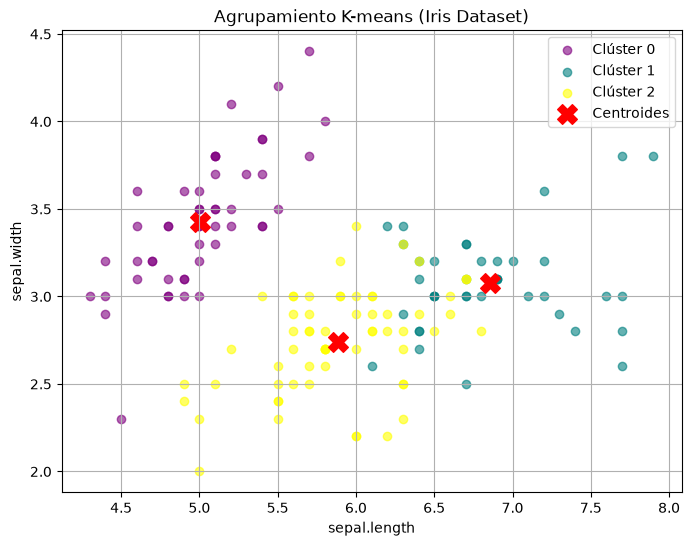

In [180]:
graficar(X, resultado['etiquetas'], resultado['centroides_finales'], columnas)